# Creation of Synthetic Neural Responses

### Synthetic Neural Responses

Synthetic neural responses are idealised firing (FR) rates in response to a patch ("receptive field") of an image taken from a dataset such as cifar10 or mnist. The patch is choosen randomly. The FR is calculated starting from the dot product between the patch and a "response filter", i.e. the preferred 2D stimulus pattern for the idealised neuron. This 2D pattern is aclled metaphorically STA in the code and can be made from periodic patterns, perlin noise, random noise, or a CNN activation.  
The combination that I am now preferring is periodic patterns with 70x70 patches of cifar10 dataset.  
The dot product is then modified including a baseline, a response threshold and a maximum firing rate. Also noise from an uniform distribution is added.

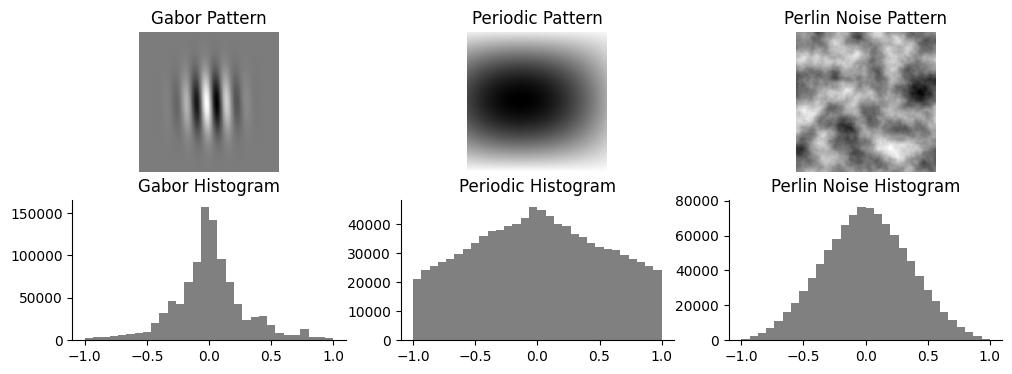

Gabor Pattern: mean=0.0033, std=0.2919
Periodic Pattern: mean=0.0052, std=0.5264
Perlin Noise Pattern: mean=0.0033, std=0.3453


In [1]:
# Example patterns
from neurodecoders.synthetic.sta import STA
import matplotlib.pyplot as plt
import numpy as np


gabor = STA().get_simulated_sta(type="gabor,100,100", length=100)
periodic_pattern = STA().get_simulated_sta(type="periodic_patterns,100,100", length=100)
perlin_noise_pattern = STA().get_simulated_sta(type="perlin_noise_patterns,100,100", length=100)

fig, axs = plt.subplots(2, 3, figsize=(12, 4))
axs[0, 0].imshow(gabor[0], cmap='gray')
axs[0, 0].set_title('Gabor Pattern')
axs[0, 1].imshow(periodic_pattern[0], cmap='gray')
axs[0, 1].set_title('Periodic Pattern')
axs[0, 2].imshow(perlin_noise_pattern[0], cmap='gray')
axs[0, 2].set_title('Perlin Noise Pattern')
#  no axes for the images
for ax in axs[0]:   
    ax.axis('off')

#  now histograms
axs[1, 0].hist(gabor.flatten(), bins=30, color='gray')
axs[1, 0].set_title('Gabor Histogram')
axs[1, 1].hist(periodic_pattern.flatten(), bins=30, color='gray')
axs[1, 1].set_title('Periodic Histogram')
axs[1, 2].hist(perlin_noise_pattern.flatten(), bins=30, color='gray')
axs[1, 2].set_title('Perlin Noise Histogram')

#  remove top and right spines for histograms
for ax in axs[1]:   
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.show()  

#  print mean and std of each pattern
print(f'Gabor Pattern: mean={np.mean(gabor):.4f}, std={np.std(gabor):.4f}')
print(f'Periodic Pattern: mean={np.mean(periodic_pattern):.4f}, std={np.std(periodic_pattern):.4f}')
print(f'Perlin Noise Pattern: mean={np.mean(perlin_noise_pattern):.4f}, std={np.std(perlin_noise_pattern):.4f}')

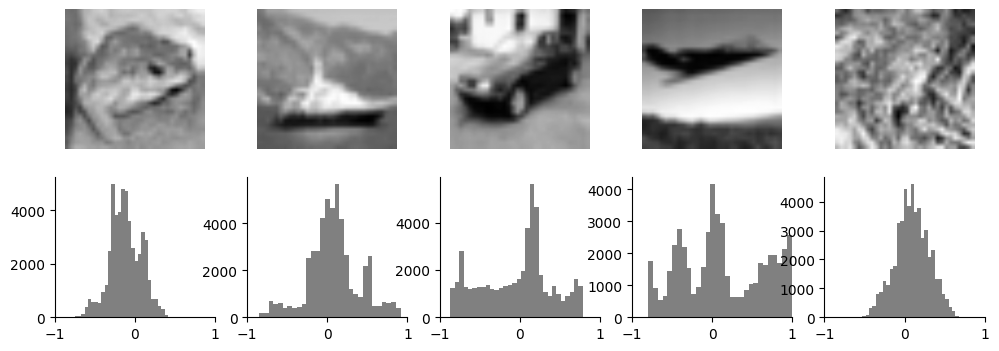

CIFAR10: mean=-0.0275, std=0.4510
CIFAR10: mean_min=-0.8611, mean_max=0.8078


In [2]:
# look at cifar10 statistics
from neurodecoders.synthetic.image_datasets import ImageDataset
images, labes = ImageDataset().get_data(type='cifar10', n_images=100)

#  remove empty axis
cifar10 = images.squeeze()

#  plot a few cifar10 images and their histograms
fig, axs = plt.subplots(2, 5, figsize=(12, 4))
for i in range(5):
    axs[0, i].imshow(cifar10[i], cmap='gray')
    axs[0, i].axis('off')
    axs[1, i].hist(cifar10[i].flatten(), bins=30, color='gray')
    axs[1, i].spines['top'].set_visible(False)
    axs[1, i].spines['right'].set_visible(False)
    axs[1, i].set_xlim([-1, 1])
plt.show()

#  print mean and std of cifar10
print(f'CIFAR10: mean={cifar10.mean():.4f}, std={cifar10.std():.4f}')
#  print mean min and max
min_for_every_image = [cifar10[i].min() for i in range(cifar10.shape[0])]
max_for_every_image = [cifar10[i].max() for i in range(cifar10.shape[0])]
print(f'CIFAR10: mean_min={np.mean(min_for_every_image):.4f}, mean_max={np.mean(max_for_every_image):.4f}')

Preparing data for batch computation...
Processing 100 images in 1 batches of 100


Processing batches:   0%|          | 0/1 [00:00<?, ?it/s]

Processing batches: 100%|██████████| 1/1 [00:00<00:00, 12.20it/s]

  Extracting patches for batch 1/1...
  Computing neural responses for batch 1/1...
Dot Products: min=-1112.2499, max=1221.0839
Thresholded Dot Products: min=0.0000, max=1221.0839
Gaussian Noise: min=-2.6762, max=2.6291
Final Firing Rates: min=0.0000, max=102.2628


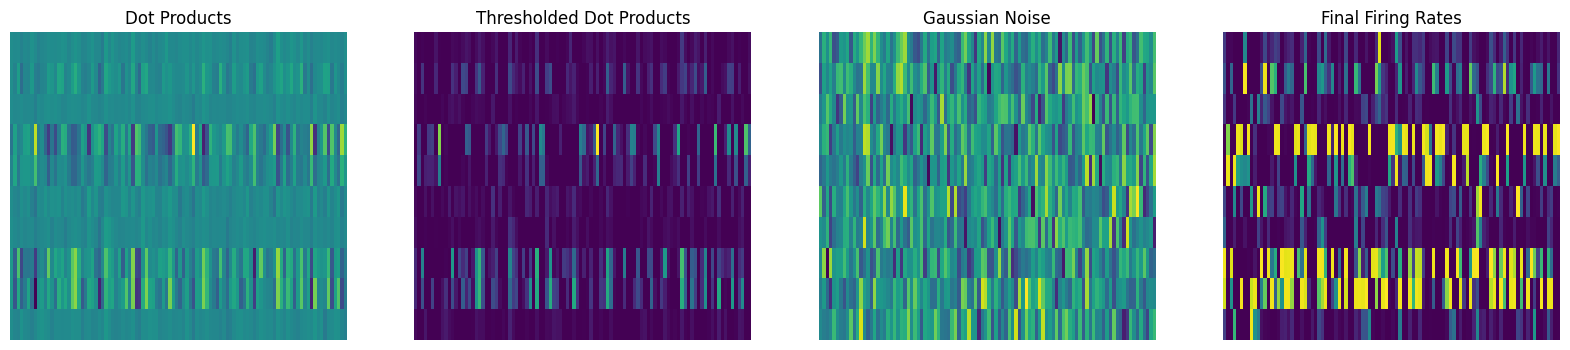

In [3]:
from neurodecoders.synthetic.simulate_response import SimulateResponse

simulator = SimulateResponse(
    device="cpu",
    images=images,
    stas=gabor,
    n_neurons=10)

firing_rates, dot_products, noises = simulator.simulate_neural_responses_vectorized()

#  plot
#  subplot 0: dot products
#  subplot 1: thresholded dot products (vmin=0)
#  subplot 2: gaussian noise
#  subplot 3: final firing rates



fig, ax = plt.subplots(1, 4, figsize=(20, 4))

ax[0].imshow(dot_products.T, aspect='auto', cmap='viridis')
ax[0].set_title('Dot Products')
#  print min and max of dot products
print(f'Dot Products: min={dot_products.min():.4f}, max={dot_products.max():.4f}')

ax[1].imshow(dot_products.T, aspect='auto', cmap='viridis', vmin=0)
ax[1].set_title('Thresholded Dot Products')
print(f'Thresholded Dot Products: min={np.clip(dot_products, 0, None).min():.4f}, max={np.clip(dot_products, 0, None).max():.4f}')

ax[2].imshow(noises.T, aspect='auto', cmap='viridis')
ax[2].set_title('Gaussian Noise')
print(f'Gaussian Noise: min={noises.min():.4f}, max={noises.max():.4f}')

im = ax[3].imshow(firing_rates.T, aspect='auto', cmap='viridis')
ax[3].set_title('Final Firing Rates')
print(f'Final Firing Rates: min={firing_rates.min():.4f}, max={firing_rates.max():.4f}')

#  axis off
for a in ax:
    a.axis('off')

#  add y and x label only for first subplot
ax[0].set_ylabel('Neurons')
ax[0].set_xlabel('Images')

plt.show()

In [1]:
# Load generated datasets
from pathlib import Path

path_to_main_folder = Path("/ceph/margrie/laura/neurodecoders")
path_to_workspace = path_to_main_folder / "workspace"
path_to_synthetic_data = path_to_workspace / "datasets" / "synthetic" / "train" 

all_datasets = list(path_to_synthetic_data.glob("*.npz"))
datasets = []
for dataset in all_datasets:
    if "20250904" in dataset.name:
        print(dataset.name)
        datasets.append(dataset)


synthdata_dataset-cifar10_sta-perlin_noise_patterns,11,11_n_neurons-100_n_images-8000_split-train_datetime-20250904_125739.npz
synthdata_dataset-cifar10_sta-perlin_noise_patterns,11,11_n_neurons-10_n_images-80_split-train_datetime-20250904_123840.npz
synthdata_dataset-cifar10_sta-perlin_noise_patterns,11,11_n_neurons-10_n_images-80_split-train_datetime-20250904_150153.npz


In [9]:
# let's look at the small dataset and see what there is inside
import numpy as np

small_dataset_path = datasets[2]
data = np.load(small_dataset_path)
data.files

['images',
 'responses',
 'stas',
 'rf_coords',
 'adaptation_states',
 'labels',
 'sta_avg_correlations']

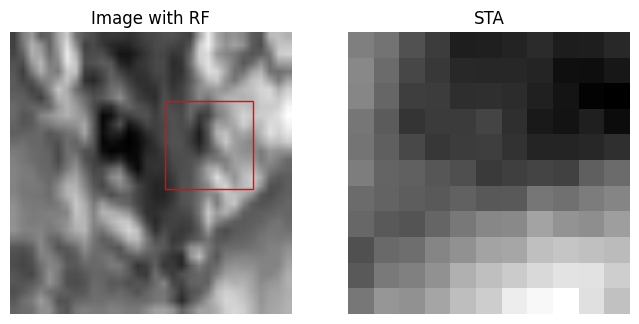

Firing rate for the first neuron and first image: 51.95 Hz


In [10]:
# Let's plot one example of image and STA and also a bounding box of the 70x70 RF
import matplotlib.pyplot as plt

image = data["images"][0][0, :, :]  # first image, first channel
sta = data["stas"][0]
rf_coords = data["rf_coords"][0]

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(image, cmap="gray")
rect = plt.Rectangle(
    (rf_coords[0], rf_coords[1]), 70, 70, linewidth=1, edgecolor="r", facecolor="none"
)
ax[0].add_patch(rect)   
ax[0].set_title("Image with RF")
ax[1].imshow(sta, cmap="gray")
ax[1].set_title("STA")
ax[0].axis("off")
ax[1].axis("off")
plt.show()

#  let's also print the firing rate for this neuron and this image
firing_rate = data["responses"][0][0]  # first neuron, first image
print(f"Firing rate for the first neuron and first image: {firing_rate:.2f} Hz")

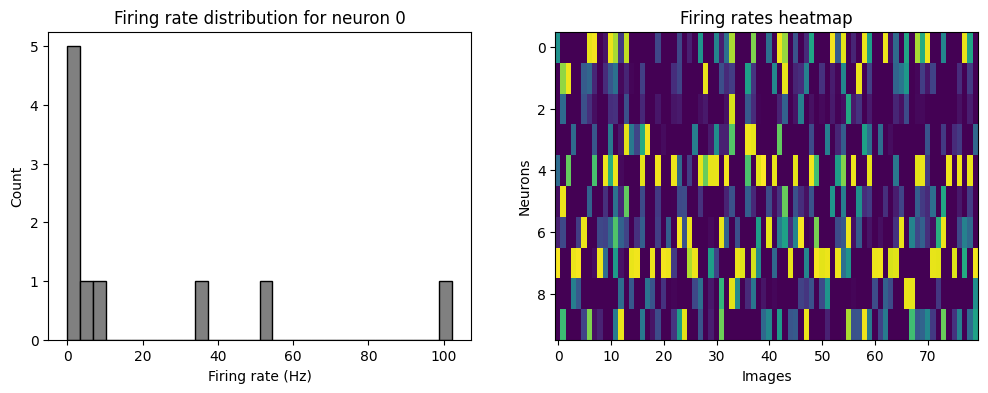

In [12]:
# plot the distribution of firing rates for this neuron

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(data["responses"][0], bins=30, color="gray", edgecolor="black")
ax[0].set_title("Firing rate distribution for neuron 0")
ax[0].set_xlabel("Firing rate (Hz)")
ax[0].set_ylabel("Count")
ax[1].imshow(data["responses"].T, aspect="auto", cmap="viridis")
ax[1].set_title("Firing rates heatmap")
ax[1].set_xlabel("Images")
ax[1].set_ylabel("Neurons")
plt.show()


In [13]:
# let's look at the big dataset and create z-scored neuron average images 
# to see if they look like the STA
from neurodecoders.synthetic.create_zscored_neuron_averages import (
    create_zscore_neuron_average_images,
)

big_dataset_path = datasets[0]
big_data = np.load(big_dataset_path)

average_images_zscore = create_zscore_neuron_average_images(
        big_data["images"], big_data["responses"], n_neurons=10
    )

KeyboardInterrupt: 

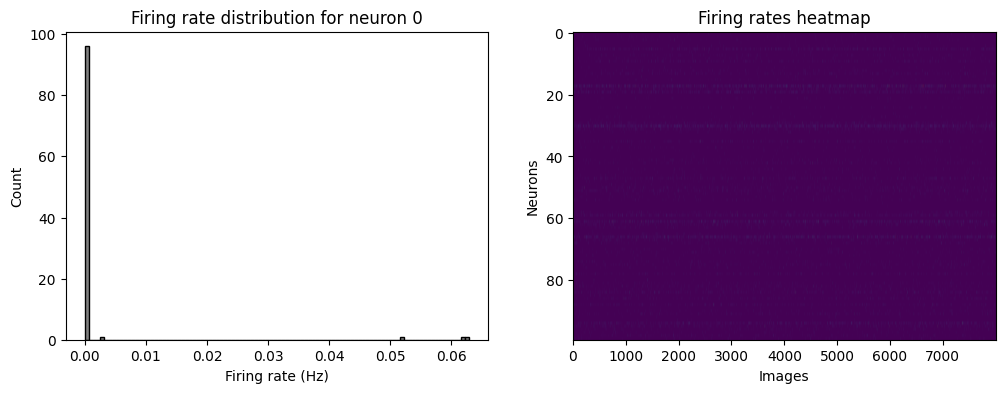

In [34]:
# plot the distribution of firing rates for this neuron

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(big_data["responses"][0], bins=100, color="gray", edgecolor="black")
ax[0].set_title("Firing rate distribution for neuron 0")
ax[0].set_xlabel("Firing rate (Hz)")
ax[0].set_ylabel("Count")
ax[1].imshow(big_data["responses"].T, aspect="auto", cmap="viridis")
ax[1].set_title("Firing rates heatmap")
ax[1].set_xlabel("Images")
ax[1].set_ylabel("Neurons")
plt.show()



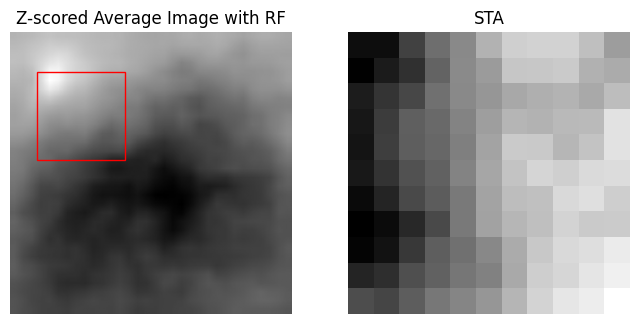

In [30]:
neuron_id = 5

#  plot the z-scored average image and the patch bounding box
sta = big_data["stas"][neuron_id]
rf_coords = big_data["rf_coords"][neuron_id]
zscore_image = average_images_zscore[neuron_id][0, :, :]  
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(zscore_image, cmap="gray")
rect = plt.Rectangle(
    (rf_coords[0], rf_coords[1]), 70, 70, linewidth=1, edgecolor="r", facecolor="none"
)
ax[0].add_patch(rect)
ax[0].set_title("Z-scored Average Image with RF")
ax[1].imshow(sta, cmap="gray")
ax[1].set_title("STA")
ax[0].axis("off")
ax[1].axis("off")
plt.show()


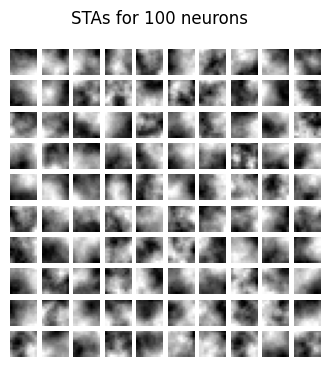

In [25]:
stas = big_data["stas"]

# plot the STA
fig, ax = plt.subplots(10, 10, figsize=(4, 4))
for i in range(10):
    for j in range(10):
        neuron_id = i * 10 + j
        ax[i, j].imshow(stas[neuron_id], cmap="gray")
        ax[i, j].axis("off")
plt.suptitle("STAs for 100 neurons")
plt.show()
